# Evaluation: BiEncoder vs BM25


## Metrics

| Metric | What it measures |
|---|---|
| **MRR@10** | Mean Reciprocal Rank — average of 1/rank of the correct result |
| **R@1** | Was the top-1 result correct? (= precision / accuracy) |
| **R@5** | Was the correct result anywhere in the top 5? |
| **R@10** | Was the correct result anywhere in the top 10? |

## Expected results
- BM25 is a strong baseline for technical documents.
- BiEncoder should outperform BM25 on **semantic / paraphrase** queries where the exact keywords don't appear in the relevant chunk.

## Setup

In [1]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/NLP PROJECT/Neural_Search_Engine-main'
    sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)
    !pip install -q transformers tokenizers safetensors rank-bm25
else:
    PROJECT_ROOT = os.path.abspath('..')
    sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)

import torch
import json
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from src.model import BiEncoder
from src.vector_store import VectorStore
from src.evaluate import evaluate_biencoder, evaluate_bm25, comparison_table, qualitative_comparison

print('Setup complete.')

Mounted at /content/drive
Setup complete.


Load Data and Models

In [2]:
# Load corpus
with open('data/processed/jurafsky_chunks_v2.json', encoding='utf-8') as f:
    chunks = json.load(f)

# Load evaluation set (10 hand-crafted queries)
eval_df = pd.read_csv('data/evaluation_set.csv')

print(f'Corpus chunks : {len(chunks)}')
print(f'Test queries  : {len(eval_df)}')
print()
print('Test queries:')
for i, row in eval_df.iterrows():
    print(f"  [{i+1}] {row['query'][:90]}")
    print(f"       expected: {row['expected_chunk_id']}")

Corpus chunks : 1410
Test queries  : 25

Test queries:
  [1] What is the standard notation for the activation function and hidden state of intermediate
       expected: chunk_0317
  [2] How can we compute the probability of a full sentence using bigram probabilities?
       expected: chunk_0062
  [3] How does an encoder-decoder model compute the probability of a target text given a source 
       expected: chunk_0783
  [4] Why is beam search preferred over greedy search and exhaustive search in machine translati
       expected: chunk_0695
  [5] How does BERT use the [CLS] token to predict the similarity score between a query and a do
       expected: chunk_0638
  [6] What is the concept of temperature sampling and how does it affect word probabilities?
       expected: chunk_0397
  [7] Who proposed the skip-gram and CBOW algorithms for neural net language models?
       expected: chunk_0294
  [8] Why is the raw dot product considered problematic as a similarity metric for very long do

In [3]:
#Tokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

#Pre-trained (no fine-tuning) BiEncoder
model_pretrained = BiEncoder()
model_pretrained.eval()

store_pretrained = VectorStore(model_pretrained, tokenizer, batch_size=64)
store_pretrained.build(chunks)

#Fine-tuned BiEncoder
model_finetuned = BiEncoder()
model_finetuned.load_state_dict(
    torch.load('checkpoints/best.pt', map_location='cpu')
)
model_finetuned.eval()

store_finetuned = VectorStore(model_finetuned, tokenizer, batch_size=64)
store_finetuned.build(chunks)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building index for 1410 chunks on cuda...
  Corpus matrix: (1410, 768)  OK


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building index for 1410 chunks on cuda...
  Corpus matrix: (1410, 768)  OK


Compute Metrics for All Three Systems

In [4]:
print('Evaluating BM25...')
bm25_metrics = evaluate_bm25(chunks, eval_df)

print('Evaluating pre-trained BiEncoder (no fine-tuning)...')
pretrained_metrics = evaluate_biencoder(store_pretrained, eval_df)

print('Evaluating fine-tuned BiEncoder...')
finetuned_metrics = evaluate_biencoder(store_finetuned, eval_df)

print('Done.')

Evaluating BM25...
Evaluating pre-trained BiEncoder (no fine-tuning)...
Evaluating fine-tuned BiEncoder...
Done.


In [5]:
# Build a three-way comparison table
metrics_keys = list(bm25_metrics.keys())
table = pd.DataFrame({
    'Metric':              metrics_keys,
    'BM25':                [bm25_metrics[k]        for k in metrics_keys],
    'BiEnc (pretrained)':  [pretrained_metrics[k]  for k in metrics_keys],
    'BiEnc (fine-tuned)':  [finetuned_metrics[k]   for k in metrics_keys],
})
table['Δ (finetuned − BM25)'] = (table['BiEnc (fine-tuned)'] - table['BM25']).round(4)

print('Results')
print(table.to_string(index=False))

Results
Metric   BM25  BiEnc (pretrained)  BiEnc (fine-tuned)  Δ (finetuned − BM25)
MRR@10 0.3833               0.118                0.19               -0.1933
   R@1 0.3200               0.080                0.12               -0.2000
   R@5 0.5200               0.200                0.28               -0.2400
  R@10 0.5600               0.200                0.28               -0.2800


Visualise Results

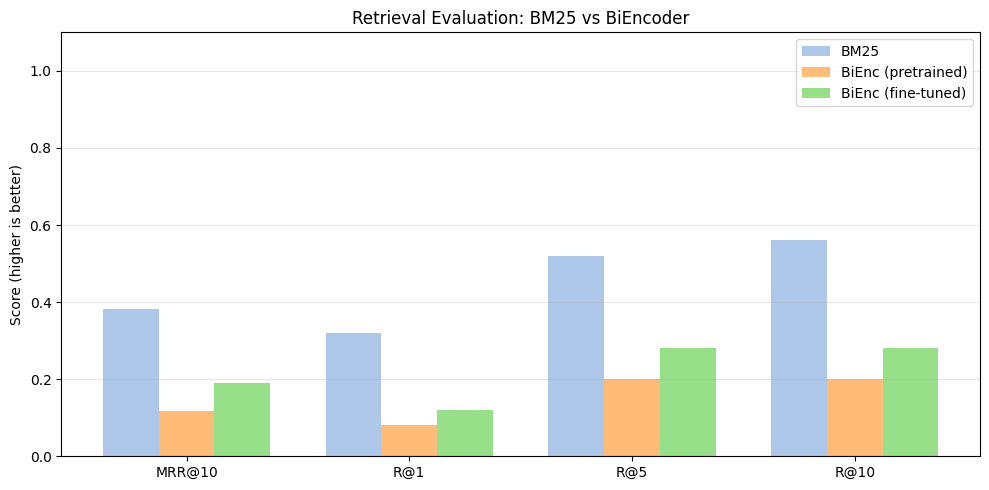

In [6]:
import numpy as np

x = np.arange(len(metrics_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, table['BM25'],               width, label='BM25',               color='#aec7e8')
ax.bar(x,         table['BiEnc (pretrained)'],  width, label='BiEnc (pretrained)', color='#ffbb78')
ax.bar(x + width, table['BiEnc (fine-tuned)'],  width, label='BiEnc (fine-tuned)', color='#98df8a')

ax.set_xticks(x)
ax.set_xticklabels(metrics_keys)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score (higher is better)')
ax.set_title('Retrieval Evaluation: BM25 vs BiEncoder')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('checkpoints/evaluation_results.png', dpi=150)
plt.show()

---
## 4. Per-Query Analysis

In [7]:
from src.evaluate import _tokenize_bm25, reciprocal_rank
from rank_bm25 import BM25Okapi

# Build BM25 once (not inside the loop)
corpus = [c['content'] for c in chunks]
chunk_ids = [c['id'] for c in chunks]
bm25 = BM25Okapi([_tokenize_bm25(d) for d in corpus])

header = '{:<60} {:>9} {:>10}  {}'.format('Query', 'BM25 rank', 'BiEnc rank', 'Winner')
print(header)
print('-' * 95)

for _, row in eval_df.iterrows():
    query = row['query']
    correct_id = row['expected_chunk_id']

    # BM25 rank of correct chunk
    scores = bm25.get_scores(_tokenize_bm25(query))
    bm25_ranked = [chunk_ids[i] for i in sorted(range(len(scores)),
                                                  key=lambda i: scores[i],
                                                  reverse=True)[:10]]
    bm25_rank = next((i + 1 for i, cid in enumerate(bm25_ranked) if cid == correct_id), 11)

    # BiEncoder rank of correct chunk
    bi_results = store_finetuned.search(query, top_k=10)
    bi_ranked  = [r['id'] for r in bi_results]
    bi_rank    = next((i + 1 for i, cid in enumerate(bi_ranked) if cid == correct_id), 11)

    if bi_rank < bm25_rank:
        winner = 'BiEnc wins'
    elif bm25_rank < bi_rank:
        winner = 'BM25 wins'
    else:
        winner = 'tie'

    bm25_display = '>10' if bm25_rank == 11 else str(bm25_rank)
    bi_display   = '>10' if bi_rank   == 11 else str(bi_rank)
    print('{:<60} {:>9} {:>10}  {}'.format(query[:58], bm25_display, bi_display, winner))

Query                                                        BM25 rank BiEnc rank  Winner
-----------------------------------------------------------------------------------------------
What is the standard notation for the activation function            3        >10  BM25 wins
How can we compute the probability of a full sentence usin         >10        >10  tie
How does an encoder-decoder model compute the probability            4        >10  BM25 wins
Why is beam search preferred over greedy search and exhaus           1        >10  BM25 wins
How does BERT use the [CLS] token to predict the similarit           2          1  BiEnc wins
What is the concept of temperature sampling and how does i           1          2  BM25 wins
Who proposed the skip-gram and CBOW algorithms for neural            1          4  BM25 wins
Why is the raw dot product considered problematic as a sim           1          2  BM25 wins
How is the attention mechanism used to compute context vec         >10     

Qualitative Comparison

In [8]:
queries_to_show = eval_df['query'].tolist()[:2]

for query in queries_to_show:
    print('=' * 80)
    print(f'QUERY: {query}')
    print()

    bi_results = store_finetuned.search(query, top_k=3)

    from rank_bm25 import BM25Okapi
    corpus = [c['content'] for c in chunks]
    chunk_ids = [c['id'] for c in chunks]
    bm25 = BM25Okapi([_tokenize_bm25(d) for d in corpus])
    bm25_scores = bm25.get_scores(_tokenize_bm25(query))
    top3 = sorted(range(len(bm25_scores)), key=lambda i: bm25_scores[i], reverse=True)[:3]

    print(f'{"BM25 results":<50} | {"BiEncoder results"}')
    print('-' * 100)
    for rank in range(3):
        bm_id = chunk_ids[top3[rank]]
        bm_text = corpus[top3[rank]][:80]
        bi_id = bi_results[rank]['id']
        bi_text = bi_results[rank]['content'][:80]
        print(f'[{rank+1}] {bm_id}: {bm_text}...')
        print(f'    BiEnc [{rank+1}] {bi_id}: {bi_text}...')
        print()
    print()

QUERY: What is the standard notation for the activation function and hidden state of intermediate layers in a feedforward network?

BM25 results                                       | BiEncoder results
----------------------------------------------------------------------------------------------------
[1] chunk_0318: By contrast, in Chapter 4 the features were mainly designed by hand via feature ...
    BiEnc [1] chunk_0310: That means the hidden layers will learn to form useful representations. This int...

[2] chunk_0319: So by this terminology logistic regression is a 1-layer network. 6.3 • FEEDFORWA...
    BiEnc [2] chunk_0776: The outputs are a new hidden state, ht and an updated context, ct. h x xt xt ht-...

[3] chunk_0317: There is a convenient function for normalizing a vector of real values, by which...
    BiEnc [3] chunk_0741: These weights determine how the network makes use of past context in calculating...


QUERY: How can we compute the probability of a full sentence u

The eval set has three flavors of queries:
- **`keyword`** — 10 queries that share heavy vocabulary with their target chunk.
  BM25 should dominate here because keyword overlap is its native strength.
- **`paraphrase`** — 10 queries that target the SAME chunks as the keyword
  queries but phrased with synonyms. This is where BiEncoder should shine.
- **`paraphrase_new`** — 5 queries on different topics across the book,
  also written with paraphrased vocabulary.

In [9]:
from src.evaluate import metrics_by_query_type

# Compute BM25 and fine-tuned BiEncoder metrics, sliced by query_type
by_type_finetuned = metrics_by_query_type(chunks, store_finetuned, eval_df)

# Pivot into a wide table: rows = (query_type, metric), columns = system
pivoted = (
    by_type_finetuned
    .pivot_table(index=['query_type', 'metric'], columns='system', values='score')
    .reset_index()
)
pivoted['Delta (BiEnc - BM25)'] = (pivoted['BiEncoder'] - pivoted['BM25']).round(4)

print(pivoted.to_string(index=False))

    query_type metric   BM25  BiEncoder  Delta (BiEnc - BM25)
       keyword MRR@10 0.6083      0.225               -0.3833
       keyword    R@1 0.5000      0.100               -0.4000
       keyword   R@10 0.8000      0.400               -0.4000
       keyword    R@5 0.8000      0.400               -0.4000
    paraphrase MRR@10 0.0300      0.050                0.0200
    paraphrase    R@1 0.0000      0.000                0.0000
    paraphrase   R@10 0.2000      0.100               -0.1000
    paraphrase    R@5 0.1000      0.100                0.0000
paraphrase_new MRR@10 0.6400      0.400               -0.2400
paraphrase_new    R@1 0.6000      0.400               -0.2000
paraphrase_new   R@10 0.8000      0.400               -0.4000
paraphrase_new    R@5 0.8000      0.400               -0.4000


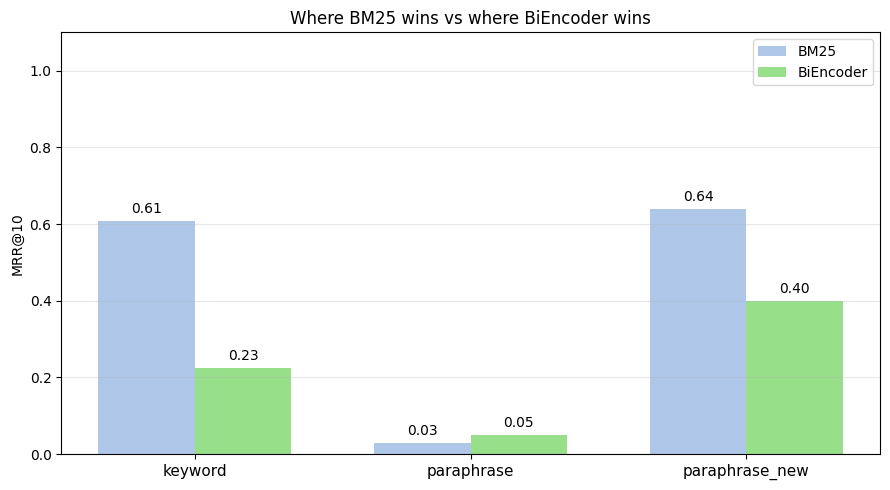

In [10]:
# Visualize MRR@10 per query_type
mrr_only = by_type_finetuned[by_type_finetuned['metric'] == 'MRR@10']
pivot_mrr = mrr_only.pivot_table(index='query_type', columns='system', values='score')

order = ['keyword', 'paraphrase', 'paraphrase_new']
pivot_mrr = pivot_mrr.reindex([o for o in order if o in pivot_mrr.index])

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pivot_mrr))
width = 0.35
ax.bar(x - width/2, pivot_mrr['BM25'],     width, label='BM25',     color='#aec7e8')
ax.bar(x + width/2, pivot_mrr['BiEncoder'], width, label='BiEncoder', color='#98df8a')

ax.set_xticks(x)
ax.set_xticklabels(pivot_mrr.index, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('MRR@10')
ax.set_title('Where BM25 wins vs where BiEncoder wins')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, qt in enumerate(pivot_mrr.index):
    ax.text(i - width/2, pivot_mrr.loc[qt, 'BM25'] + 0.02,
            f"{pivot_mrr.loc[qt, 'BM25']:.2f}", ha='center', fontsize=10)
    ax.text(i + width/2, pivot_mrr.loc[qt, 'BiEncoder'] + 0.02,
            f"{pivot_mrr.loc[qt, 'BiEncoder']:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('checkpoints/mrr_by_query_type.png', dpi=150)
plt.show()